### 서울시 인구 분포와 서울시 CCTV 설치 현황(갯수)데이터를 가지고 데이터 분석 및 시각화하셔요.
- 서울시 각 구별 cctv 수를 파악하고 인구대비 cctv 비율을 구해 순위 비교
- 인구대비 cctv의 평균치를 확인하고 cctv가 과하게 부족한 구를 확인
- 고령자 대비 cctv 비율
- 외국인 대비 cctv 비율

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import json
import platform
import matplotlib.font_manager as font_manager
import matplotlib as mpl

system = platform.system()
if system == "Windows":
    font_path = "C:/Windows/Fonts/malgun.ttf"
elif system == "Darwin":
    font_path = "/System/Library/Fonts/AppleSDGothicNeo.ttc"
elif system == "Linux":
    font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
else:
    font_path = None
if font_path:
    font = font_manager.FontProperties(fname=font_path).get_name()
    mpl.rcParams['font.family'] = font
else:
    print("폰트 경로를 확인해주세요.")

mpl.rcParams['axes.unicode_minus'] = False

#여러변수출력코드
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity="all"

In [43]:
cctv_df = pd.read_excel("../../data/cctv_result.xlsx", index_col='구별')

In [44]:
cctv_df.head()

,소계,최근증가율,인구수,한국인,외국인,고령자,외국인비율,고령자비율,CCTV비율
구별,,,,,,,,,
강남구,3238,150.619195,570500,565550,4950,63167,0.867660,11.072217,0.567572
강동구,1010,166.490765,453233,449019,4214,54622,0.929765,12.051638,0.222843
강북구,831,125.203252,330192,326686,3506,54813,1.061806,16.600342,0.251672
강서구,911,134.793814,603772,597248,6524,72548,1.080540,12.015794,0.150885
관악구,2109,149.290780,525515,507203,18312,68082,3.484582,12.955291,0.401321


In [45]:
cctv_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25 entries, 강남구 to 중랑구
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   소계      25 non-null     int64  
 1   최근증가율   25 non-null     float64
 2   인구수     25 non-null     int64  
 3   한국인     25 non-null     int64  
 4   외국인     25 non-null     int64  
 5   고령자     25 non-null     int64  
 6   외국인비율   25 non-null     float64
 7   고령자비율   25 non-null     float64
 8   CCTV비율  25 non-null     float64
dtypes: float64(4), int64(5)
memory usage: 2.0+ KB


In [46]:
cctv_df.describe()

,소계,최근증가율,인구수,한국인,외국인,고령자,외국인비율,고령자비율,CCTV비율
count,25.000000,25.000000,25.00000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000
mean,1515.320000,119.030748,407904.16000,397078.720000,10825.440000,52858.320000,3.105648,13.284569,0.412226
std,616.774656,61.350043,130273.67526,131802.414218,8301.513236,14173.072031,2.489046,1.588524,0.213095
min,825.000000,34.671731,133240.00000,124312.000000,2017.000000,20764.000000,0.578524,10.862599,0.150885
25%,1010.000000,64.973730,330192.00000,326686.000000,4445.000000,48161.000000,0.958451,12.051638,0.251508
50%,1327.000000,104.347826,412520.00000,400456.000000,8928.000000,54173.000000,2.526635,12.955291,0.383295
75%,1884.000000,150.619195,479978.00000,475949.000000,14747.000000,63167.000000,4.172440,14.661322,0.510093
max,3238.000000,248.922414,667483.00000,660584.000000,34913.000000,72548.000000,8.663598,16.600342,0.994350


In [47]:
# CCTV비율 순위
cctv_df['CCTV비율_순위'] = cctv_df['CCTV비율'].rank(method='dense', ascending=False)
cctv_df

,소계,최근증가율,인구수,한국인,외국인,고령자,외국인비율,고령자비율,CCTV비율,CCTV비율_순위
구별,,,,,,,,,,
강남구,3238,150.619195,570500,565550,4950,63167,0.867660,11.072217,0.567572,4.0
강동구,1010,166.490765,453233,449019,4214,54622,0.929765,12.051638,0.222843,22.0
강북구,831,125.203252,330192,326686,3506,54813,1.061806,16.600342,0.251672,18.0
강서구,911,134.793814,603772,597248,6524,72548,1.080540,12.015794,0.150885,25.0
관악구,2109,149.290780,525515,507203,18312,68082,3.484582,12.955291,0.401321,12.0
광진구,878,53.228621,372164,357211,14953,42214,4.017852,11.342849,0.235917,21.0
구로구,1884,64.973730,447874,416487,31387,56833,7.007998,12.689506,0.420654,11.0
금천구,1348,100.000000,255082,236353,18729,32970,7.342345,12.925255,0.528458,5.0
노원구,1566,188.929889,569384,565565,3819,71941,0.670725,12.634883,0.275034,17.0


In [48]:
# 서울시 인구 대비 CCTV 평균 비율
cctv_mean = cctv_df['소계'].sum() / cctv_df['인구수'].sum() * 100
cctv_mean
cctv_median = cctv_df['CCTV비율'].median()
cctv_median
# 인구 대비 CCTV 평균 비율보다 작은 구를 찾기
cctv_df2 = cctv_df[cctv_df['CCTV비율'] < cctv_median]
cctv_df2

np.float64(0.37148922433151943)

0.383295177021851

,소계,최근증가율,인구수,한국인,외국인,고령자,외국인비율,고령자비율,CCTV비율,CCTV비율_순위
구별,,,,,,,,,,
강동구,1010,166.490765,453233,449019,4214,54622,0.929765,12.051638,0.222843,22.0
강북구,831,125.203252,330192,326686,3506,54813,1.061806,16.600342,0.251672,18.0
강서구,911,134.793814,603772,597248,6524,72548,1.080540,12.015794,0.150885,25.0
광진구,878,53.228621,372164,357211,14953,42214,4.017852,11.342849,0.235917,21.0
노원구,1566,188.929889,569384,565565,3819,71941,0.670725,12.634883,0.275034,17.0
도봉구,825,246.638655,348646,346629,2017,51312,0.578524,14.717507,0.236630,20.0
동작구,1302,139.338235,412520,400456,12064,56013,2.924464,13.578251,0.315621,16.0
마포구,980,212.101911,389649,378566,11083,48765,2.844355,12.515110,0.251508,19.0
성북구,1651,63.627354,461260,449773,11487,64692,2.490353,14.025062,0.357933,14.0


In [49]:
# 고령자 대비 CCTV 비율
cctv_df['CCTV비율_고령자'] = cctv_df['소계'] / cctv_df['고령자'] * 100
cctv_df.head()

,소계,최근증가율,인구수,한국인,외국인,고령자,외국인비율,고령자비율,CCTV비율,CCTV비율_순위,CCTV비율_고령자
구별,,,,,,,,,,,
강남구,3238,150.619195,570500,565550,4950,63167,0.867660,11.072217,0.567572,4.0,5.126094
강동구,1010,166.490765,453233,449019,4214,54622,0.929765,12.051638,0.222843,22.0,1.849072
강북구,831,125.203252,330192,326686,3506,54813,1.061806,16.600342,0.251672,18.0,1.516064
강서구,911,134.793814,603772,597248,6524,72548,1.080540,12.015794,0.150885,25.0,1.255720
관악구,2109,149.290780,525515,507203,18312,68082,3.484582,12.955291,0.401321,12.0,3.097735


In [50]:
# 외국인 대비 CCTV 비율
cctv_df['CCTV비율_외국인'] = cctv_df['소계'] / cctv_df['외국인'] * 100
cctv_df.head()

,소계,최근증가율,인구수,한국인,외국인,고령자,외국인비율,고령자비율,CCTV비율,CCTV비율_순위,CCTV비율_고령자,CCTV비율_외국인
구별,,,,,,,,,,,,
강남구,3238,150.619195,570500,565550,4950,63167,0.867660,11.072217,0.567572,4.0,5.126094,65.414141
강동구,1010,166.490765,453233,449019,4214,54622,0.929765,12.051638,0.222843,22.0,1.849072,23.967727
강북구,831,125.203252,330192,326686,3506,54813,1.061806,16.600342,0.251672,18.0,1.516064,23.702225
강서구,911,134.793814,603772,597248,6524,72548,1.080540,12.015794,0.150885,25.0,1.255720,13.963826
관악구,2109,149.290780,525515,507203,18312,68082,3.484582,12.955291,0.401321,12.0,3.097735,11.517038


In [51]:
# 구별 CCTV 설치 현황 시각화
def load_data(col_name, temp_df):
    geo_path='../../data/02. skorea_municipalities_geo_simple.json'
    geo_str = json.load(open(geo_path,encoding='utf-8'))

    map=folium.Map(
        location=[37.5502,126.982],
        zoom_start=11,
        tiles='OpenStreetMap'
    )
    folium.Choropleth(
        geo_data=geo_str,
        data=temp_df,
        columns=[temp_df.index,
        col_name],
        key_on = 'feature.id',
        fill_color='YlGnBu',
        fill_opacity=0.7,
        line_color='gray',
        line_weight=1,
        legend_name=f'구별 {col_name}',
        bins=25
    ).add_to(map)

    for feature in geo_str['features']:
        district_name = feature['properties']['name']
        if district_name in temp_df.index:
            cal_data = temp_df.loc[district_name, col_name]
            feature['properties']['display_text'] = f"{district_name} ({cal_data})"

    folium.GeoJson(
        geo_str,
        tooltip=folium.GeoJsonTooltip(fields=['display_text'], aliases=[f'구 이름({col_name}):'])
    ).add_to(map)
    folium.LayerControl().add_to(map)
    return map

<Axes: xlabel='CCTV비율_순위', ylabel='구별'>

Text(0.5, 1.0, '구별 CCTV 비율 순위')

Text(0.5, 0, 'CCTV 비율 순위')

Text(0, 0.5, '구')

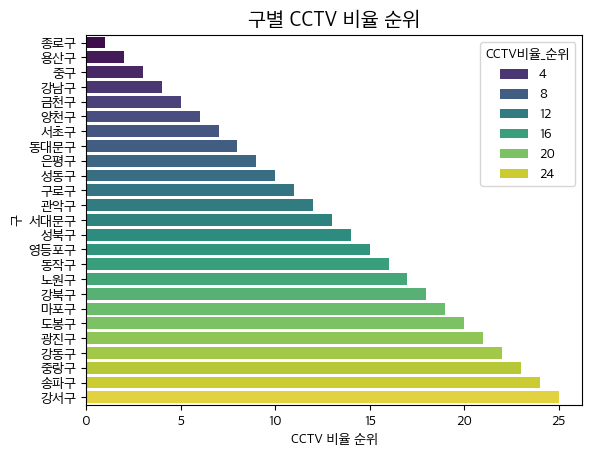

In [52]:
# 서울시 각 구별 cctv 수를 파악하고 인구대비 cctv 비율을 구해 순위 비교
cctv_df_sorted = cctv_df.sort_values(by='CCTV비율_순위', ascending=True)
sns.barplot(x='CCTV비율_순위', y=cctv_df_sorted.index, data=cctv_df_sorted, palette='viridis', hue='CCTV비율_순위')
plt.title('구별 CCTV 비율 순위', fontsize=15)
plt.xlabel('CCTV 비율 순위')
plt.ylabel('구')
plt.show()
map = load_data('CCTV비율', cctv_df)
map

<Axes: xlabel='CCTV비율', ylabel='구별'>

Text(0.5, 1.0, '평균 이하 구별 CCTV비율')

Text(0.5, 0, 'CCTV 비율')

Text(0, 0.5, '구')

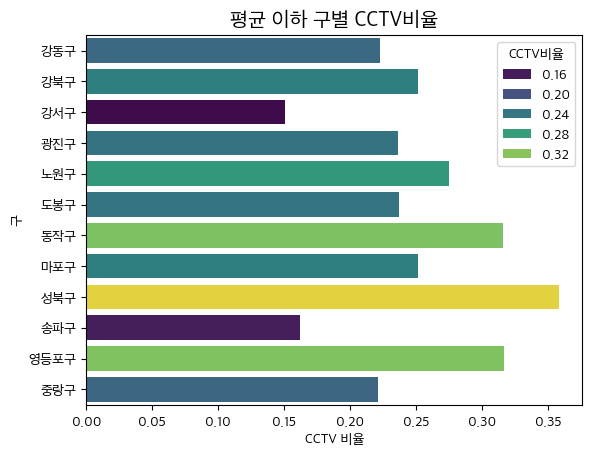

In [53]:
# 인구대비 cctv의 평균치를 확인하고 cctv가 과하게 부족한 구를 확인
sns.barplot(x='CCTV비율', y=cctv_df2.index, data=cctv_df2, palette='viridis', hue='CCTV비율', estimator=np.mean)
plt.title('평균 이하 구별 CCTV비율', fontsize=15)
plt.xlabel('CCTV 비율')
plt.ylabel('구')
plt.show()
map = load_data('CCTV비율', cctv_df2)
map

In [54]:
# 고령자 대비 cctv 비율
map = load_data('CCTV비율_고령자', cctv_df)
map

In [55]:
# 외국인 대비 cctv 비율
map = load_data('CCTV비율_외국인', cctv_df)
map